# Дополнительный модуль: источники данных, строки, регулярные выражения и файлы

Этот ноутбук продолжает тему **«Сбор данных с различных источников. Основы работы с SQL»**.

В первых файлах мы работали с MySQL: создавали таблицы `users` и `orders`, писали SQL-запросы, соединяли таблицы через `JOIN`. Но в реальной работе аналитик получает данные не только из базы данных. Данные часто приходят из разных источников:

- CSV-файлов;
- Excel-файлов;
- JSON-файлов;
- текстовых полей;
- выгрузок из CRM, сайтов, форм и внутренних систем.

Цель этого ноутбука — показать, как после получения данных привести их в порядок: проверить типы, очистить строки, извлечь нужные части текста, объединить таблицы и сохранить результат в разные форматы.

## Что слушатель должен понять

После прохождения ноутбука слушатель должен уметь:

- отличать числовой тип данных от строкового;
- преобразовывать данные через `astype()`;
- работать со строковыми столбцами через `.str`;
- фильтровать email, URL и текстовые записи;
- извлекать части строки через регулярные выражения;
- добавлять строки в `Series` и `DataFrame` через `pd.concat()`;
- строить простые графики;
- создавать `DataFrame` из словаря и списка словарей;
- читать и записывать CSV, Excel и JSON;
- понимать, где такие операции встречаются после SQL-выгрузки.

## 1. Подготовка библиотек

Нам понадобятся:

- `pandas` — для таблиц;
- `matplotlib` — для простых графиков;
- `Path` из `pathlib` — чтобы удобно работать с папками и файлами.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.2f}'.format

DATA_DIR = Path('data_sources_demo')
DATA_DIR.mkdir(exist_ok=True)

print('Папка для учебных файлов:', DATA_DIR.resolve())

Папка для учебных файлов: /mnt/data/data_sources_demo


## 2. Типы данных: число, строка и обратное преобразование

В SQL мы уже видели разные типы данных:

```sql
age INT,
balance DECIMAL(10, 2),
email VARCHAR(50)
```

В pandas у каждого столбца тоже есть тип данных. Это важно, потому что число и строка ведут себя по-разному.

Например, число `25` можно сравнивать и складывать. А строка `'25 лет'` уже не число: её сначала нужно очистить и преобразовать обратно.

In [2]:
users_age = pd.DataFrame({
    'name': ['Ivan', 'Gleb', 'Sergey'],
    'age': [25, 26, 28]
})

print('Исходная таблица:')
display(users_age)
print('\nТипы данных:')
print(users_age.dtypes)

Исходная таблица:


,name,age
0,Ivan,25
1,Gleb,26
2,Sergey,28



Типы данных:
name    object
age      int64
dtype: object


Добавим текстовое представление возраста. Такая ситуация часто встречается в «грязных» выгрузках: вместо числа в ячейке может быть строка вида `25 лет`.

In [3]:
users_age['age_text'] = users_age['age'].astype(str) + ' лет'

display(users_age)
print(users_age.dtypes)

,name,age,age_text
0,Ivan,25,25 лет
1,Gleb,26,26 лет
2,Sergey,28,28 лет


name        object
age          int64
age_text    object
dtype: object


Теперь восстановим число из строки:

1. уберём текст ` лет`;
2. преобразуем результат в `int`.

In [4]:
users_age['age_recovered'] = (
    users_age['age_text']
    .str.replace(' лет', '', regex=False)
    .astype(int)
)

display(users_age)
print(users_age.dtypes)

,name,age,age_text,age_recovered
0,Ivan,25,25 лет,25
1,Gleb,26,26 лет,26
2,Sergey,28,28 лет,28


name             object
age               int64
age_text         object
age_recovered     int64
dtype: object


### Мини-задание 1

Создайте таблицу `salary_df` с колонкой `salary` и значениями `[145000, 152000, 161000]`.

Затем:

1. создайте новую колонку `salary_text` в формате `145000 руб.`;
2. восстановите из неё числовую колонку `salary_recovered`;
3. проверьте типы данных.

In [5]:
# Место для самостоятельной работы слушателя

## 3. Строковые методы: email и домены

В базах данных часто есть поля с email, телефонами, адресами сайтов, комментариями. Формально это строки, но внутри строки есть полезная структура.

Например, по email можно понять домен: `example.com`, `example.org`, `company.ru`.

In [6]:
emails = pd.DataFrame({
    'user_id': [1, 2, 3, 4, 5, 6],
    'email': [
        'ivan@example.com',
        'gleb@example.com',
        'sergey@example.org',
        'andrew@company.ru',
        'bob@example.com',
        'tom@company.ru'
    ]
})

display(emails)

,user_id,email
0,1,ivan@example.com
1,2,gleb@example.com
2,3,sergey@example.org
3,4,andrew@company.ru
4,5,bob@example.com
5,6,tom@company.ru


Отфильтруем строки, где email заканчивается на `.com`.

Здесь используется регулярное выражение `\.com$`:

- `\.` означает точку как обычный символ;
- `com` — текст `com`;
- `$` — конец строки.

In [7]:
mask_com = emails['email'].str.contains(r'\.com$', regex=True)

print('Булева маска:')
print(mask_com)

print('\nТолько email с доменом .com:')
display(emails[mask_com])

Булева маска:
0     True
1     True
2    False
3    False
4     True
5    False
Name: email, dtype: bool

Только email с доменом .com:


,user_id,email
0,1,ivan@example.com
1,2,gleb@example.com
4,5,bob@example.com


Теперь извлечём домен после символа `@`.

In [8]:
emails['domain'] = emails['email'].str.extract(r'@(.+)$')
display(emails)

,user_id,email,domain
0,1,ivan@example.com,example.com
1,2,gleb@example.com,example.com
2,3,sergey@example.org,example.org
3,4,andrew@company.ru,company.ru
4,5,bob@example.com,example.com
5,6,tom@company.ru,company.ru


### Мини-задание 2

Создайте таблицу `urls` с колонкой `url`:

```python
['https://site.org', 'http://example.com', 'https://docs.org', 'https://shop.ru']
```

Затем:

1. отфильтруйте адреса, которые заканчиваются на `.org`;
2. создайте колонку `is_https`, где будет `True`, если адрес начинается с `https`;
3. извлеките доменную зону: `org`, `com`, `ru`.

In [9]:
# Место для самостоятельной работы слушателя

## 4. Извлечение данных из текстовых записей

Иногда данные приходят не в нормальной таблице, а в одном текстовом поле.

Например:

```text
id=105; user=Alice; score=92
```

В такой строке спрятаны три разных признака: `id`, `user`, `score`.

In [10]:
records = pd.DataFrame({
    'record': [
        'id=105; user=Alice; score=92',
        'id=106; user=Bob; score=85',
        'id=107; user=Charlie; score=97',
        'id=108; user=Diana; score=78'
    ]
})

display(records)

,record
0,id=105; user=Alice; score=92
1,id=106; user=Bob; score=85
2,id=107; user=Charlie; score=97
3,id=108; user=Diana; score=78


Извлечём значения через `.str.extract()`.

Регулярное выражение ниже содержит группы в круглых скобках:

- `(\d+)` — одна или несколько цифр;
- `([A-Za-z]+)` — одно или несколько латинских букв.

In [11]:
records[['id', 'user', 'score']] = records['record'].str.extract(
    r'id=(\d+); user=([A-Za-z]+); score=(\d+)'
)

records['id'] = records['id'].astype(int)
records['score'] = records['score'].astype(int)

display(records)
print(records.dtypes)

,record,id,user,score
0,id=105; user=Alice; score=92,105,Alice,92
1,id=106; user=Bob; score=85,106,Bob,85
2,id=107; user=Charlie; score=97,107,Charlie,97
3,id=108; user=Diana; score=78,108,Diana,78


record    object
id         int64
user      object
score      int64
dtype: object


Теперь можно анализировать извлечённые значения как обычные столбцы.

In [12]:
print('Средний score:', records['score'].mean())
print('Максимальный score:', records['score'].max())

print('\nПользователи со score >= 90:')
display(records[records['score'] >= 90])

Средний score: 88.0
Максимальный score: 97

Пользователи со score >= 90:


,record,id,user,score
0,id=105; user=Alice; score=92,105,Alice,92
2,id=107; user=Charlie; score=97,107,Charlie,97


### Мини-задание 3

Создайте таблицу с колонкой `raw_order`:

```python
[
    'order=1; product=Book; qty=2',
    'order=2; product=Mouse; qty=1',
    'order=3; product=Keyboard; qty=3'
]
```

Извлеките в отдельные колонки:

- `order_id`;
- `product`;
- `qty`.

Колонки `order_id` и `qty` должны быть числовыми.

In [13]:
# Место для самостоятельной работы слушателя

## 5. Добавление данных через `pd.concat()`

В старых примерах pandas часто можно встретить добавление строк через `append()`. В современных версиях pandas для добавления строк и объединения таблиц используют `pd.concat()`.

Смысл простой: мы не «дописываем» строку в таблицу вручную, а объединяем две таблицы или две серии.

In [14]:
scores = pd.Series([5, 10, 15], name='score')
print('Исходная Series:')
print(scores)

Исходная Series:
0     5
1    10
2    15
Name: score, dtype: int64


In [15]:
scores = pd.concat([
    scores,
    pd.Series([20, 25], name='score')
], ignore_index=True)

print('После добавления значений в конец:')
print(scores)

После добавления значений в конец:
0     5
1    10
2    15
3    20
4    25
Name: score, dtype: int64


In [16]:
scores = pd.concat([
    pd.Series([0], name='score'),
    scores
], ignore_index=True)

print('После добавления значения в начало:')
print(scores)

После добавления значения в начало:
0     0
1     5
2    10
3    15
4    20
5    25
Name: score, dtype: int64


Теперь добавим строки в `DataFrame`.

In [17]:
clients = pd.DataFrame({
    'name': ['Ivan', 'Gleb', 'Sergey'],
    'age': [25, 26, 28],
    'country': ['RUS', 'RUS', 'RUS']
})

new_clients = pd.DataFrame([
    {'name': 'Andrew', 'age': 24, 'country': 'RUS'},
    {'name': 'Tom', 'age': 29, 'country': 'USA'}
])

clients = pd.concat([clients, new_clients], ignore_index=True)
display(clients)

,name,age,country
0,Ivan,25,RUS
1,Gleb,26,RUS
2,Sergey,28,RUS
3,Andrew,24,RUS
4,Tom,29,USA


### Мини-задание 4

Создайте таблицу `products` с колонками:

- `product_name`;
- `price`;
- `quantity`.

Затем создайте ещё одну таблицу `new_products` с двумя новыми товарами и объедините их через `pd.concat()`.

In [18]:
# Место для самостоятельной работы слушателя

## 6. Простые графики

График помогает быстро увидеть динамику или сравнение.

На этом этапе нам не нужно строить сложную визуализацию. Достаточно понять принцип:

- линейный график — хорошо показывает динамику;
- столбчатая диаграмма — хорошо сравнивает категории.

In [19]:
daily_revenue = pd.Series(
    [20, 65, 45, 24, 25],
    index=pd.to_datetime(['2023-02-20', '2023-02-22', '2023-02-23', '2023-02-25', '2023-02-26']),
    name='revenue'
)

display(daily_revenue)

2023-02-20    20
2023-02-22    65
2023-02-23    45
2023-02-25    24
2023-02-26    25
Name: revenue, dtype: int64

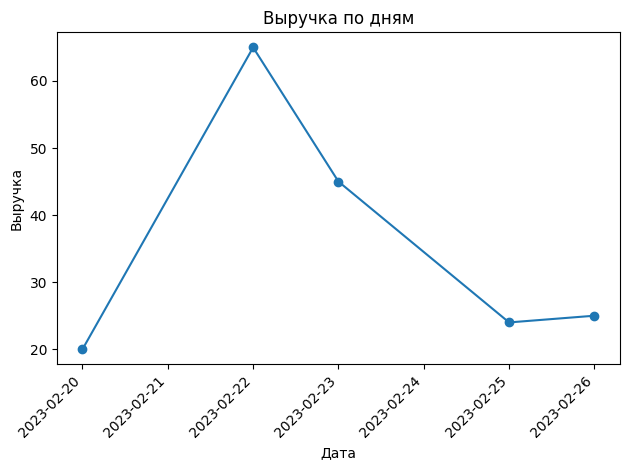

In [20]:
ax = daily_revenue.plot(kind='line', marker='o', title='Выручка по дням')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

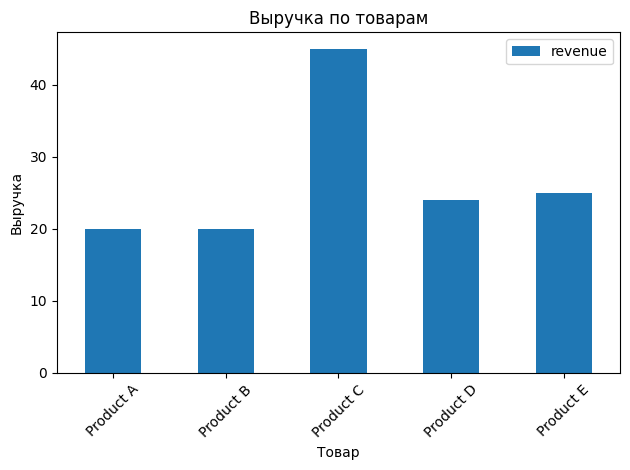

In [21]:
product_revenue = pd.DataFrame({
    'product_name': ['Product A', 'Product B', 'Product C', 'Product D', 'Product E'],
    'revenue': [20, 20, 45, 24, 25]
})

ax = product_revenue.plot(x='product_name', y='revenue', kind='bar', title='Выручка по товарам')
plt.xlabel('Товар')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Мини-задание 5

Создайте `Series` со значениями `[2, 4, 1, 5, 3]` и постройте линейный график.

Затем создайте `DataFrame` с тремя колонками `sales_A`, `sales_B`, `sales_C` и постройте столбчатую диаграмму.

In [22]:
# Место для самостоятельной работы слушателя

## 7. Словари и DataFrame

В Python словарь часто похож на одну запись из JSON или одну строку из внешней системы.

Например, товар может быть представлен так:

In [23]:
product = {
    'name': 'Keyboard',
    'price': 3500,
    'qty': 2
}

print(product)

{'name': 'Keyboard', 'price': 3500, 'qty': 2}


Словарь можно обновлять: менять существующие значения и добавлять новые ключи.

In [24]:
product['price'] = 3700
product['in_stock'] = True

for key, value in product.items():
    print(key, '->', value)

name -> Keyboard
price -> 3700
qty -> 2
in_stock -> True


Список словарей легко превращается в таблицу `DataFrame`.

In [25]:
cities = [
    {'city': 'Moscow', 'population_mln': 12.6},
    {'city': 'Saint Petersburg', 'population_mln': 5.6},
    {'city': 'Kazan', 'population_mln': 1.3}
]

cities_df = pd.DataFrame(cities)
cities_df = cities_df.set_index('city').sort_values('population_mln', ascending=False)
display(cities_df)

,population_mln
city,
Moscow,12.60
Saint Petersburg,5.60
Kazan,1.30


### Мини-задание 6

Создайте словарь `order` с полями:

- `product`;
- `price`;
- `qty`.

Затем:

1. измените цену;
2. добавьте поле `status`;
3. выведите все ключи и значения;
4. создайте `DataFrame` из списка таких словарей.

In [26]:
# Место для самостоятельной работы слушателя

## 8. CSV: самый частый формат обмена таблицами

CSV — это текстовый файл, где строки таблицы записаны построчно, а значения разделены символом-разделителем, чаще всего запятой или точкой с запятой.

CSV часто используют для обмена данными между системами, BI-инструментами и аналитиками.

In [27]:
students = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Charlie'],
    'age': [24, 30, 40],
    'course': ['DA', 'BI', 'Python'],
    'grade': ['A', 'B', 'A']
})

display(students)

,name,age,course,grade
0,Alice,24,DA,A
1,Bob,30,BI,B
2,Charlie,40,Python,A


In [28]:
csv_path = DATA_DIR / 'students.csv'

students.to_csv(csv_path, index=False, encoding='utf-8')
print('CSV-файл записан:', csv_path)

CSV-файл записан: data_sources_demo/students.csv


In [29]:
students_from_csv = pd.read_csv(csv_path, encoding='utf-8')

display(students_from_csv)
print(students_from_csv.dtypes)

,name,age,course,grade
0,Alice,24,DA,A
1,Bob,30,BI,B
2,Charlie,40,Python,A


name      object
age        int64
course    object
grade     object
dtype: object


### Важное замечание про CSV

Если файл открывается в Excel некорректно, проблема часто не в pandas, а в:

- кодировке;
- разделителе;
- региональных настройках Excel.

Для русскоязычных Excel-файлов иногда используют `sep=';'` и `encoding='utf-8-sig'`.

In [30]:
csv_semicolon_path = DATA_DIR / 'students_semicolon.csv'

students.to_csv(csv_semicolon_path, index=False, sep=';', encoding='utf-8-sig')
print('CSV с разделителем ; записан:', csv_semicolon_path)

CSV с разделителем ; записан: data_sources_demo/students_semicolon.csv


## 9. Excel: привычный формат для пользователей бизнеса

Excel удобен для передачи таблиц между людьми, но для автоматической обработки данных его нужно читать аккуратно:

- указывать лист;
- проверять заголовки;
- проверять типы данных;
- следить за пустыми строками.

In [31]:
excel_path = DATA_DIR / 'students.xlsx'

try:
    students.to_excel(excel_path, index=False, sheet_name='Students')
    print('Excel-файл записан:', excel_path)
except Exception as error:
    print('Не удалось записать Excel-файл.')
    print('Возможная причина: не установлен пакет openpyxl.')
    print('Ошибка:', repr(error))

Excel-файл записан: data_sources_demo/students.xlsx


In [32]:
try:
    students_from_excel = pd.read_excel(excel_path, sheet_name='Students')
    display(students_from_excel)
    print(students_from_excel.dtypes)
except Exception as error:
    print('Не удалось прочитать Excel-файл.')
    print('Возможная причина: не установлен пакет openpyxl.')
    print('Ошибка:', repr(error))

,name,age,course,grade
0,Alice,24,DA,A
1,Bob,30,BI,B
2,Charlie,40,Python,A


name      object
age        int64
course    object
grade     object
dtype: object


## 10. JSON: формат для обмена между приложениями

JSON часто используется в API, веб-сервисах и внутренних системах.

Для аналитика важно понимать, что JSON может быть:

- списком объектов;
- вложенной структурой;
- одной записью;
- набором строк, где каждая строка — отдельный JSON-объект.

В этом ноутбуке используем простой вариант: список объектов.

In [33]:
json_path = DATA_DIR / 'students.json'

students.to_json(json_path, orient='records', force_ascii=False, indent=2)
print('JSON-файл записан:', json_path)

JSON-файл записан: data_sources_demo/students.json


In [34]:
students_from_json = pd.read_json(json_path, orient='records')

display(students_from_json)
print(students_from_json.dtypes)

,name,age,course,grade
0,Alice,24,DA,A
1,Bob,30,BI,B
2,Charlie,40,Python,A


name      object
age        int64
course    object
grade     object
dtype: object


## 11. Полный мини-пайплайн: прочитали, очистили, сохранили

Теперь соберём небольшой пример, похожий на реальную работу аналитика:

1. получили данные в CSV;
2. прочитали их в pandas;
3. очистили строковые поля;
4. извлекли домен email;
5. рассчитали новый столбец;
6. сохранили результат в CSV и JSON.

In [35]:
raw_clients = pd.DataFrame({
    'client_id': [1, 2, 3, 4],
    'name': ['  Ivan ', ' Gleb', 'Sergey  ', '  Andrew'],
    'email': ['ivan@example.com', 'gleb@example.com', 'sergey@example.org', 'andrew@company.ru'],
    'balance_text': ['100000 руб.', '110000 руб.', '90000 руб.', '95000 руб.']
})

raw_clients_path = DATA_DIR / 'raw_clients.csv'
raw_clients.to_csv(raw_clients_path, index=False, encoding='utf-8')
print('Исходная выгрузка записана:', raw_clients_path)
display(raw_clients)

Исходная выгрузка записана: data_sources_demo/raw_clients.csv


,client_id,name,email,balance_text
0,1,Ivan,ivan@example.com,100000 руб.
1,2,Gleb,gleb@example.com,110000 руб.
2,3,Sergey,sergey@example.org,90000 руб.
3,4,Andrew,andrew@company.ru,95000 руб.


In [36]:
clients_raw = pd.read_csv(raw_clients_path, encoding='utf-8')

display(clients_raw)
print(clients_raw.dtypes)

,client_id,name,email,balance_text
0,1,Ivan,ivan@example.com,100000 руб.
1,2,Gleb,gleb@example.com,110000 руб.
2,3,Sergey,sergey@example.org,90000 руб.
3,4,Andrew,andrew@company.ru,95000 руб.


client_id        int64
name            object
email           object
balance_text    object
dtype: object


In [37]:
clients_clean = clients_raw.copy()

clients_clean['name'] = clients_clean['name'].str.strip()
clients_clean['email_domain'] = clients_clean['email'].str.extract(r'@(.+)$')
clients_clean['balance'] = (
    clients_clean['balance_text']
    .str.replace(' руб.', '', regex=False)
    .astype(int)
)
clients_clean = clients_clean.drop(columns=['balance_text'])

display(clients_clean)
print(clients_clean.dtypes)

,client_id,name,email,email_domain,balance
0,1,Ivan,ivan@example.com,example.com,100000
1,2,Gleb,gleb@example.com,example.com,110000
2,3,Sergey,sergey@example.org,example.org,90000
3,4,Andrew,andrew@company.ru,company.ru,95000


client_id        int64
name            object
email           object
email_domain    object
balance          int64
dtype: object


In [38]:
clean_csv_path = DATA_DIR / 'clients_clean.csv'
clean_json_path = DATA_DIR / 'clients_clean.json'

clients_clean.to_csv(clean_csv_path, index=False, encoding='utf-8')
clients_clean.to_json(clean_json_path, orient='records', force_ascii=False, indent=2)

print('Очищенный CSV:', clean_csv_path)
print('Очищенный JSON:', clean_json_path)

Очищенный CSV: data_sources_demo/clients_clean.csv
Очищенный JSON: data_sources_demo/clients_clean.json


## 12. Итоговая практика

Выполните задания ниже самостоятельно. Они повторяют основные операции ноутбука.

### Задания

1. Создайте `DataFrame` с колонкой `Salary` и значениями `[145000, 152000, 161000]`.
2. Создайте колонку `SalaryText` в формате `145000 руб.`.
3. Извлеките обратно числовую колонку `SalaryRecovered`.
4. Создайте таблицу `URL` и отфильтруйте строки, которые заканчиваются на `.org`.
5. Извлеките из строк вида `id=105; user=Alice; score=92` пользователя и балл.
6. Добавьте значения в `Series` через `pd.concat()`.
7. Добавьте две строки в `DataFrame` через `pd.concat()`.
8. Постройте линейный график по числовой `Series`.
9. Создайте список словарей и преобразуйте его в `DataFrame`.
10. Сохраните итоговую таблицу в CSV и JSON.

In [39]:
# Итоговая практика: место для работы слушателя

## 13. Решения для самопроверки

Этот блок можно удалить из версии для слушателей, если нужно выдать файл как самостоятельное задание.

In [40]:
# Решение 1-3
salary_df = pd.DataFrame({'Salary': [145000, 152000, 161000]})
salary_df['SalaryText'] = salary_df['Salary'].astype(str) + ' руб.'
salary_df['SalaryRecovered'] = (
    salary_df['SalaryText']
    .str.replace(' руб.', '', regex=False)
    .astype(int)
)
display(salary_df)
print(salary_df.dtypes)

,Salary,SalaryText,SalaryRecovered
0,145000,145000 руб.,145000
1,152000,152000 руб.,152000
2,161000,161000 руб.,161000


Salary              int64
SalaryText         object
SalaryRecovered     int64
dtype: object


In [41]:
# Решение 4
url_df = pd.DataFrame({
    'URL': ['https://site.org', 'http://example.com', 'https://docs.org', 'https://shop.ru']
})
url_df['is_https'] = url_df['URL'].str.startswith('https')
url_df['zone'] = url_df['URL'].str.extract(r'\.([a-z]+)$')
org_urls = url_df[url_df['URL'].str.contains(r'\.org$', regex=True)]

display(url_df)
display(org_urls)

,URL,is_https,zone
0,https://site.org,True,org
1,http://example.com,False,com
2,https://docs.org,True,org
3,https://shop.ru,True,ru


,URL,is_https,zone
0,https://site.org,True,org
2,https://docs.org,True,org


In [42]:
# Решение 5
record_df = pd.DataFrame({
    'Record': [
        'id=105; user=Alice; score=92',
        'id=106; user=Bob; score=85'
    ]
})
record_df[['id', 'user', 'score']] = record_df['Record'].str.extract(
    r'id=(\d+); user=([A-Za-z]+); score=(\d+)'
)
record_df['id'] = record_df['id'].astype(int)
record_df['score'] = record_df['score'].astype(int)
display(record_df)

,Record,id,user,score
0,id=105; user=Alice; score=92,105,Alice,92
1,id=106; user=Bob; score=85,106,Bob,85


In [43]:
# Решение 6-7
s = pd.Series([5, 10, 15], name='values')
s = pd.concat([s, pd.Series([20, 25], name='values')], ignore_index=True)
s = pd.concat([pd.Series([0], name='values'), s], ignore_index=True)
print(s)

people = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [24, 30, 40]
})
new_people = pd.DataFrame([
    {'Name': 'David', 'Age': 45},
    {'Name': 'Eva', 'Age': 27}
])
people = pd.concat([people, new_people], ignore_index=True)
display(people)

0     0
1     5
2    10
3    15
4    20
5    25
Name: values, dtype: int64


,Name,Age
0,Alice,24
1,Bob,30
2,Charlie,40
3,David,45
4,Eva,27


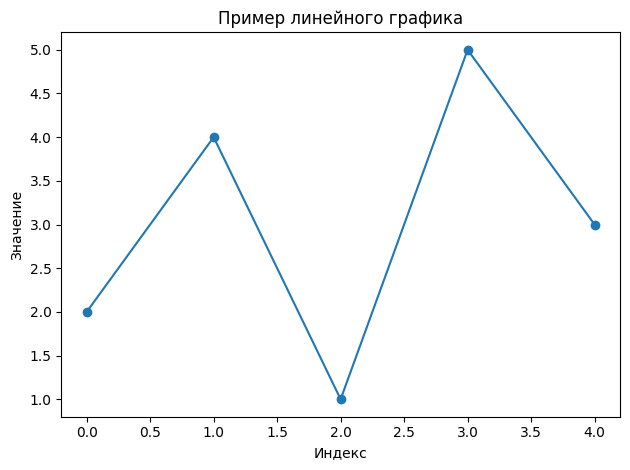

In [44]:
# Решение 8
series_for_plot = pd.Series([2, 4, 1, 5, 3], name='metric')
ax = series_for_plot.plot(kind='line', marker='o', title='Пример линейного графика')
plt.xlabel('Индекс')
plt.ylabel('Значение')
plt.tight_layout()
plt.show()

In [45]:
# Решение 9-10
products = [
    {'product': 'Book', 'price': 700, 'qty': 2},
    {'product': 'Mouse', 'price': 1500, 'qty': 1},
    {'product': 'Keyboard', 'price': 3500, 'qty': 3}
]
products_df = pd.DataFrame(products)
products_df['total'] = products_df['price'] * products_df['qty']

display(products_df)

products_csv = DATA_DIR / 'products_result.csv'
products_json = DATA_DIR / 'products_result.json'

products_df.to_csv(products_csv, index=False, encoding='utf-8')
products_df.to_json(products_json, orient='records', force_ascii=False, indent=2)

print('CSV:', products_csv)
print('JSON:', products_json)

,product,price,qty,total
0,Book,700,2,1400
1,Mouse,1500,1,1500
2,Keyboard,3500,3,10500


CSV: data_sources_demo/products_result.csv
JSON: data_sources_demo/products_result.json


## 14. Краткая шпаргалка

| Задача | pandas |
|---|---|
| Преобразовать тип | `df['col'].astype(int)` |
| Применить строковую операцию | `df['col'].str.strip()` |
| Найти строки по шаблону | `df['col'].str.contains(pattern, regex=True)` |
| Извлечь часть строки | `df['col'].str.extract(pattern)` |
| Добавить строки | `pd.concat([df1, df2], ignore_index=True)` |
| Записать CSV | `df.to_csv('file.csv', index=False)` |
| Прочитать CSV | `pd.read_csv('file.csv')` |
| Записать Excel | `df.to_excel('file.xlsx', index=False)` |
| Прочитать Excel | `pd.read_excel('file.xlsx')` |
| Записать JSON | `df.to_json('file.json', orient='records')` |
| Прочитать JSON | `pd.read_json('file.json')` |
| Построить график | `df.plot(...)` |

## 15. Типичные ошибки новичков

| Ошибка | Почему возникает | Как исправить |
|---|---|---|
| Числа хранятся как строки | В значении есть текст: `руб.`, `%`, `лет` | Сначала убрать текст, потом применить `astype()` |
| Фильтр по строке не работает | Неправильный шаблон или забыли `regex=True` | Проверить регулярное выражение на 2-3 примерах |
| После объединения странные индексы | Не указан `ignore_index=True` | Использовать `pd.concat(..., ignore_index=True)` |
| CSV читается «одной колонкой» | Не тот разделитель | Указать `sep=';'` или другой разделитель |
| Русский текст в CSV отображается некорректно | Проблема кодировки | Использовать `encoding='utf-8'` или `encoding='utf-8-sig'` |
| Excel не читается или не записывается | Не установлен движок для Excel | Установить `openpyxl` |
| JSON прочитался не так, как ожидалось | Другая структура JSON | Проверить `orient` и структуру файла |

## 16. Контрольные вопросы для преподавателя

1. Чем число `25` отличается от строки `'25 лет'`?
2. Зачем перед `astype(int)` часто нужно очищать строку?
3. Что делает `.str.contains()`?
4. Что делает `.str.extract()`?
5. Почему `pd.concat()` полезен при добавлении строк?
6. Когда лучше использовать CSV, а когда Excel?
7. Где в реальной работе встречается JSON?
8. Почему после чтения файла нужно проверять `dtypes`?
9. Чем этот ноутбук связан с SQL-выгрузками?
10. Какой минимальный набор проверок нужно сделать после получения файла от заказчика?